In [1]:
import sys, importlib.util
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

In [2]:
# %% locate this script (works in scripts; falls back to cwd inside notebooks)
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

CSV_PATH = (HERE / "../../CombinedDatasetSEC_A4.csv").resolve()
OUT_DIR  = (HERE / "outputs/multi_source").resolve()

# %% load thermoift PLOT_SETTINGS without triggering the package __init__
PLOT_SETTINGS_PATH = (HERE / "../../../../thermoift/src/thermoift/PLOT_SETTINGS.py").resolve()
_spec = importlib.util.spec_from_file_location("thermoift_plot_settings", PLOT_SETTINGS_PATH)
ps = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(ps)

In [3]:
# %% load dataset and derive residual delta gamma
df_all = pd.read_csv(CSV_PATH)
df_all["gamma_base"]  = df_all["gamma_wsd_UC"]
df_all["gamma_cDFT"]  = df_all["gamma_wsd_UC"] + df_all["gamma_cDFT_minus_wsd_uncorrected"]
df_all["delta_gamma"] = df_all["gamma_cDFT"] - df_all["gamma_base"]

keep = np.isfinite(df_all["T"]) & np.isfinite(df_all["P"]) & np.isfinite(df_all["delta_gamma"])
df_all = df_all[keep]

print(f"{df_all['source_id'].nunique()} sources, {len(df_all)} rows")

100 sources, 23043 rows


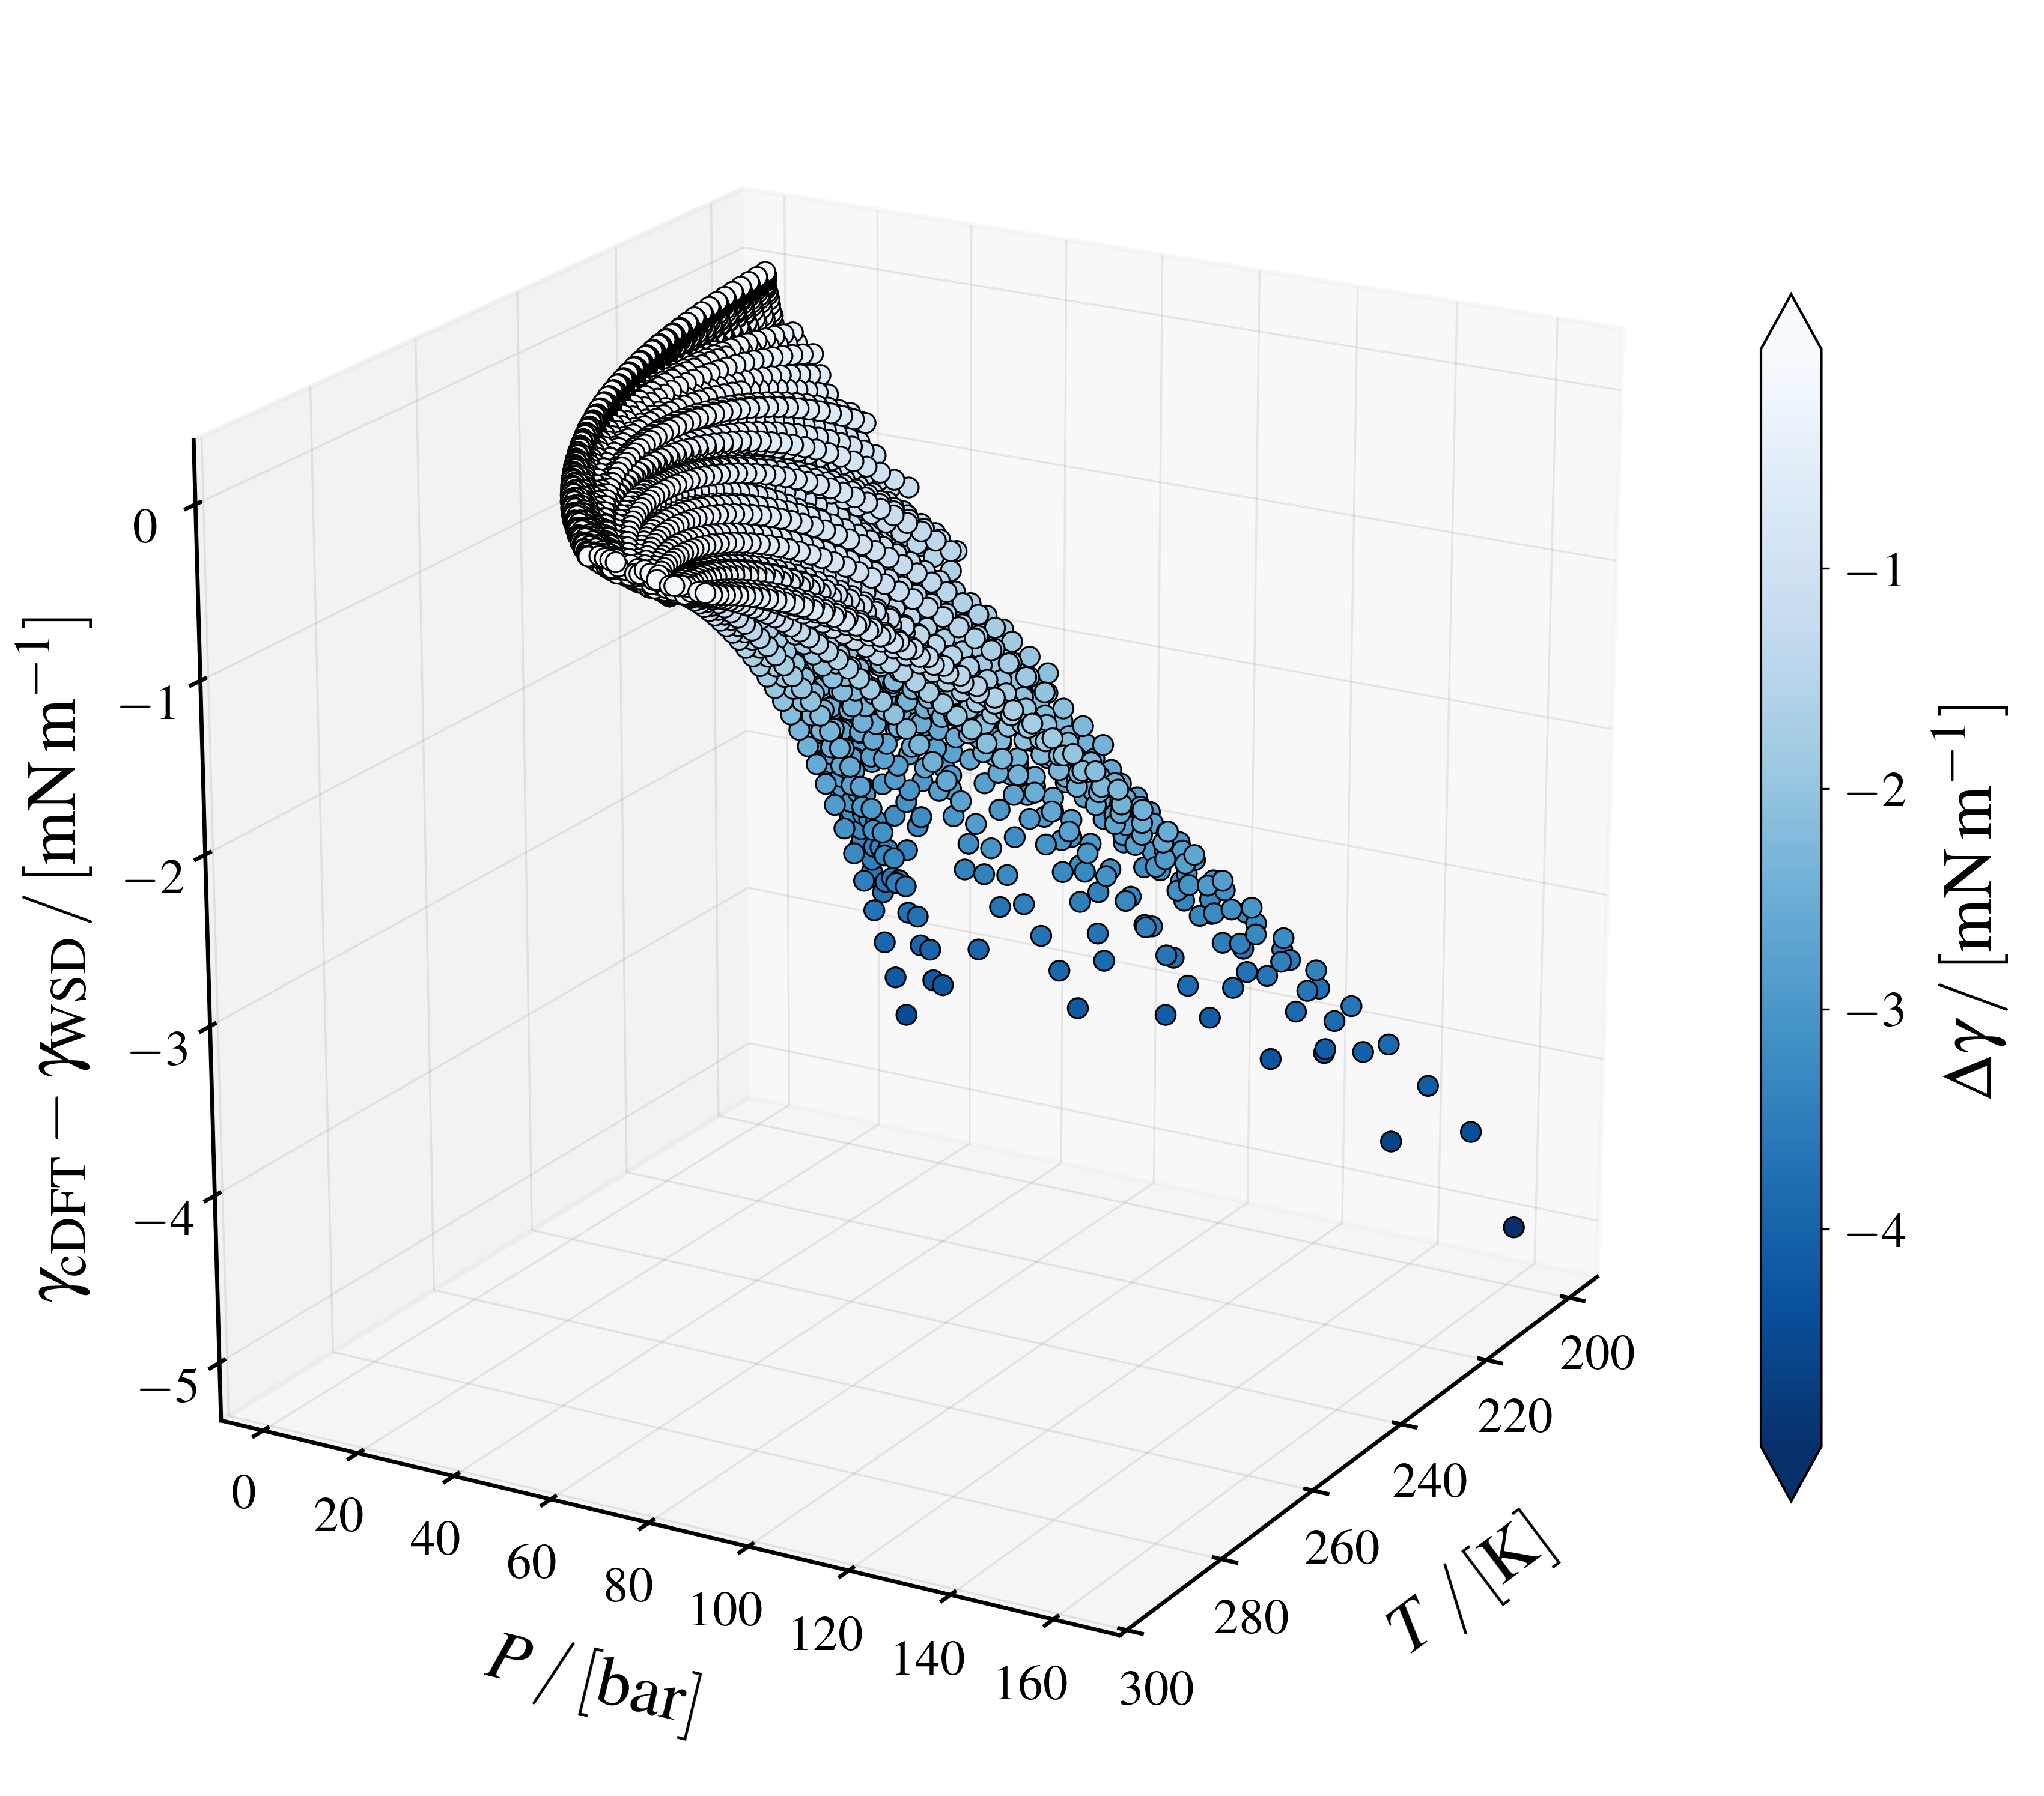

In [15]:
plt.rcParams["font.family"]      = ps.graphic_font
plt.rcParams["mathtext.fontset"] = ps.math_font
plt.rcParams["text.usetex"]      = True

AXIS_LABEL = r"$\gamma_{\mathrm{cDFT}} - \gamma_{\mathrm{WSD}} \, / \, [\mathrm{mN} \, \mathrm{m}^{-1}]$"
CBAR_LABEL = r"$\Delta\gamma \, / \, [\mathrm{mN} \, \mathrm{m}^{-1}]$"

with plt.style.context(["ieee"]):
    fig = plt.figure(figsize=(10,5.5))
    ax  = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(
        df_all["T"], df_all["P"], df_all["delta_gamma"],
        c=df_all["delta_gamma"],
        cmap="Blues_r",
        s=ps.markersize ** 2,
        edgecolor="black",
        linewidth=ps.markeredgewidth/2,
        depthshade=False,
    )

    ax.set_xlabel(ps.label_map["t"], fontsize=ps.label_fontsize, labelpad=0)
    ax.set_ylabel(ps.label_map["p"], fontsize=ps.label_fontsize, labelpad=0)
    ax.zaxis.set_rotate_label(False)
    
    ax.set_zlabel(AXIS_LABEL, fontsize=ps.label_fontsize, labelpad=-2, rotation=90)
    
    ax.tick_params(axis="both", which="major",
                   width=ps.tick_width, length=ps.tick_length,
                   labelsize=ps.tick_labelsize, pad=-2)
    for spine in ax.spines.values():
        spine.set_linewidth(ps.spine_width)

    ax.view_init(elev=20, azim=30)
    ax.set_box_aspect((0.5, 0.5, 0.5))
    ax.grid(True)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo["grid"].update({"color": (0, 0, 0, 0.08), "linewidth": 0.4})

    cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0, extend="both")
    cb.set_label(CBAR_LABEL, fontsize=ps.label_fontsize)
    ps.style_colorbar(cb)
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(width=0.4, length=1.5)
    fig.subplots_adjust(left=0.16, right=0.86, top=0.95, bottom=0.08)
    plt.show()

In [5]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
png = OUT_DIR / "residual_3d_multi.png"
pdf = OUT_DIR / "residual_3d_multi.pdf"
fig.savefig(png, dpi=ps.resolution_value, bbox_inches="tight")
fig.savefig(pdf, dpi=ps.resolution_value, bbox_inches="tight")
print(f"Saved -> {png}")
print(f"Saved -> {pdf}")

Saved -> /home/darshan/A6/PCSAFT_cDFT/PART_1/RESIDUAL/SR/Mixtures/outputs/multi_source/residual_3d_multi.png
Saved -> /home/darshan/A6/PCSAFT_cDFT/PART_1/RESIDUAL/SR/Mixtures/outputs/multi_source/residual_3d_multi.pdf
